# XWorld — Dataset 4: Keeling Curve (Mauna Loa CO2)

**Goal**: Download monthly CO2 data, decompose into seasonal cycles and long-term trend, extract features from both components separately.

**Dynamic types captured**:
- Seasonal component: regular annual cycle (breathing of the biosphere)
- Trend component: slow exponential drift (accumulation)

In [1]:
import requests
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import find_peaks
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
print('Imports OK')

Imports OK


## 1. Download from NOAA

In [2]:
# NOAA monthly CO2 — clean, well-maintained, no auth required
URL = 'https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv'
dest = RAW_DIR / 'keeling_monthly.csv'

if not dest.exists():
    print('Downloading...')
    r = requests.get(URL)
    dest.write_bytes(r.content)
    print(f'Saved to {dest}')
else:
    print(f'Already exists: {dest}')

Downloading...
Saved to ../data/raw/keeling_monthly.csv


## 2. Parse

In [3]:
# NOAA file has comment lines starting with # — skip them
df = pd.read_csv(
    dest,
    comment='#',
    header=0,
    na_values=[-99.99, -9.99]
)

# Standardize column names (NOAA format can vary slightly)
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
print('Columns:', df.columns.tolist())
df.head()

Columns: ['year', 'month', 'decimal_date', 'average', 'deseasonalized', 'ndays', 'sdev', 'unc']


,year,month,decimal_date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,NaN,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,NaN,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,NaN,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,NaN,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,NaN,-0.99


In [4]:
# Identify the CO2 average column — typically 'average' or 'monthly_average'
co2_col = [c for c in df.columns if 'average' in c and 'interpolated' not in c][0]
print(f'Using column: {co2_col}')

# Build datetime index
year_col = [c for c in df.columns if 'year' in c][0]
month_col = [c for c in df.columns if 'month' in c][0]

df['date'] = pd.to_datetime(dict(year=df[year_col], month=df[month_col], day=1))
df = df.dropna(subset=[co2_col])
df = df.set_index('date').sort_index()

co2 = df[co2_col]
print(f'Monthly records: {len(co2)}')
print(f'Date range: {co2.index.min().date()} to {co2.index.max().date()}')
print(f'CO2 range: {co2.min():.1f} to {co2.max():.1f} ppm')

Using column: average
Monthly records: 816
Date range: 1958-03-01 to 2026-02-01
CO2 range: 312.4 to 430.5 ppm


## 3. Plot the full Keeling Curve

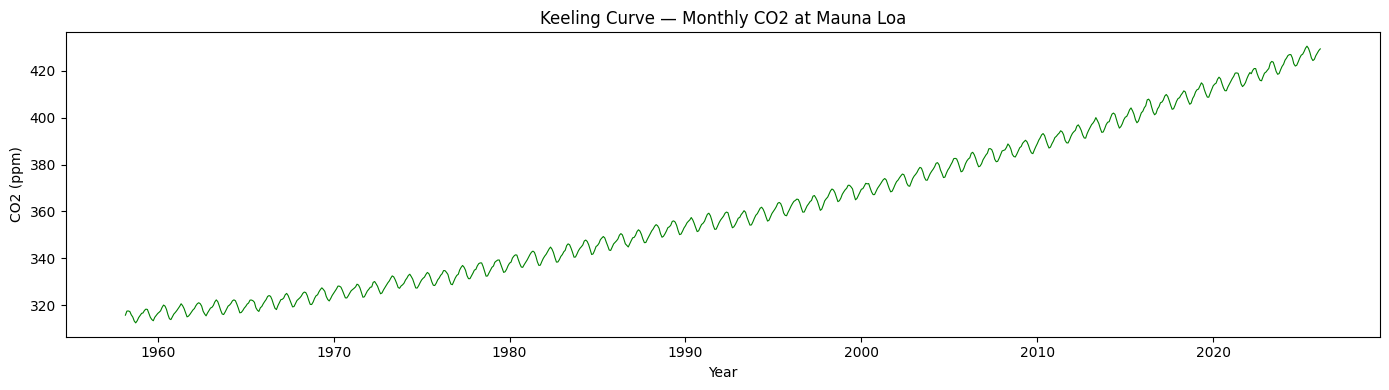

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(co2.index, co2.values, linewidth=0.8, color='green')
ax.set_title('Keeling Curve — Monthly CO2 at Mauna Loa', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('CO2 (ppm)')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'keeling_full.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Decompose: seasonal + trend

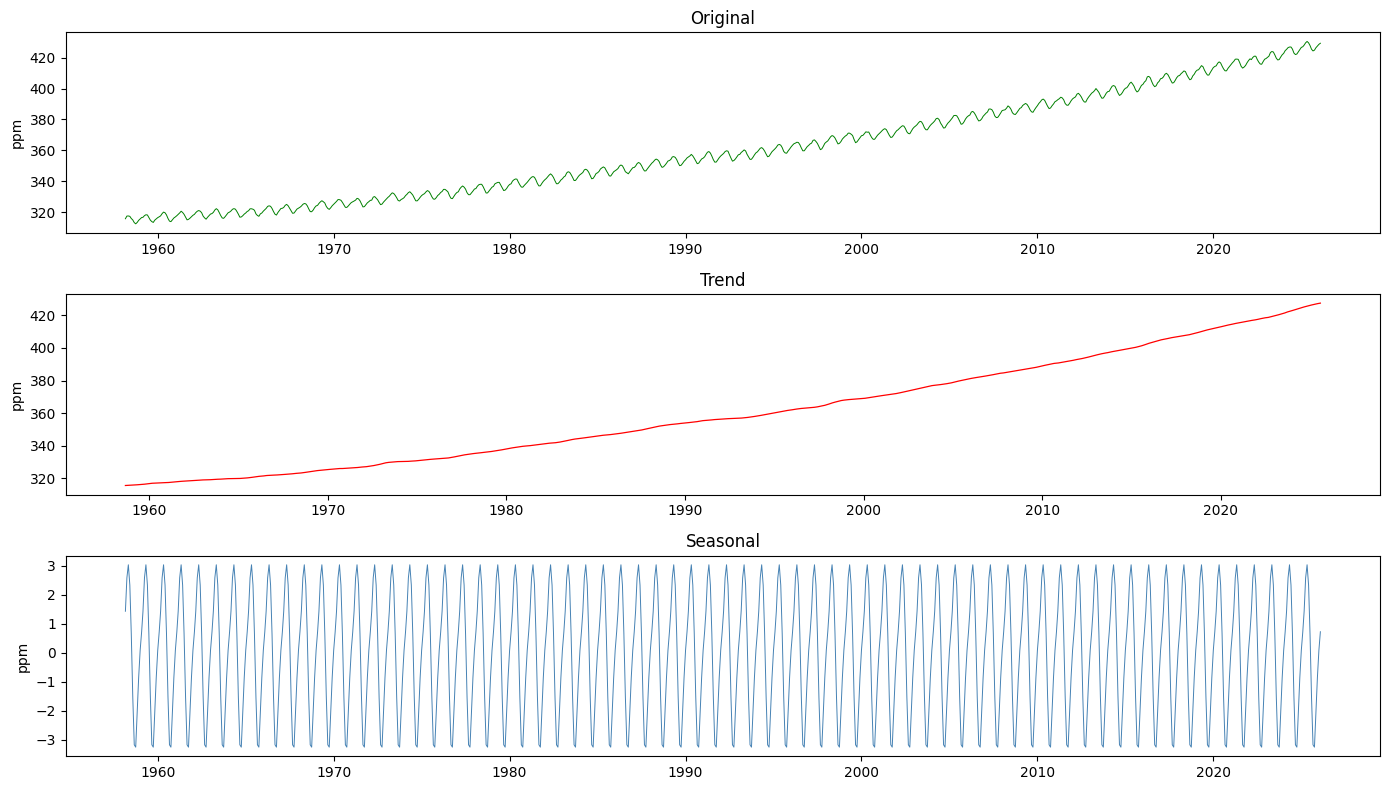

In [6]:
# Seasonal decomposition — period=12 months
result = seasonal_decompose(co2, model='additive', period=12)

fig, axes = plt.subplots(3, 1, figsize=(14, 8))
axes[0].plot(co2.index, co2.values, linewidth=0.7, color='green')
axes[0].set_title('Original')
axes[1].plot(co2.index, result.trend, linewidth=0.9, color='red')
axes[1].set_title('Trend')
axes[2].plot(co2.index, result.seasonal, linewidth=0.7, color='steelblue')
axes[2].set_title('Seasonal')
for ax in axes:
    ax.set_ylabel('ppm')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'keeling_decomposed.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Extract series instances

**From seasonal**: each individual year is one instance (12 points of the annual breathing cycle)

**From trend**: rolling 10-year windows

In [7]:
seasonal_vals = result.seasonal.dropna().values
trend_vals = result.trend.dropna().values

series_dict = {}

# Seasonal: slice into yearly 12-point segments
n_years = len(seasonal_vals) // 12
start_year = co2.index.min().year
for i in range(n_years):
    seg = seasonal_vals[i*12:(i+1)*12]
    if len(seg) == 12:
        series_dict[f'keeling_seasonal_{start_year + i}'] = seg

# Trend: rolling 10-year (120-month) windows, step 12 months
window = 120
step = 12
for i in range(0, len(trend_vals) - window, step):
    seg = trend_vals[i:i+window]
    yr = start_year + (i // 12)
    series_dict[f'keeling_trend_{yr}'] = seg

print(f'Seasonal instances: {sum(1 for k in series_dict if "seasonal" in k)}')
print(f'Trend instances: {sum(1 for k in series_dict if "trend" in k)}')

Seasonal instances: 68
Trend instances: 57


## 6. Z-score normalize and overlay both components

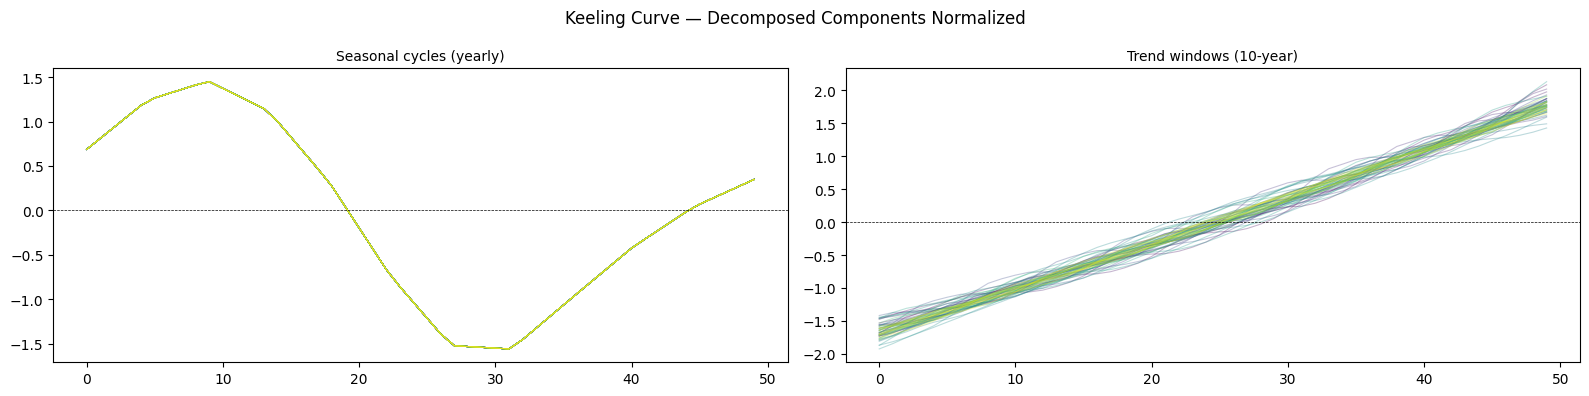

In [8]:
def zscore_normalize(s):
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()

series_norm = {name: zscore_normalize(s) for name, s in series_dict.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, key, color, title in [
    (axes[0], 'seasonal', 'steelblue', 'Seasonal cycles (yearly)'),
    (axes[1], 'trend', 'red', 'Trend windows (10-year)'),
]:
    subset = {k: v for k, v in series_norm.items() if key in k}
    colors_grad = cm.viridis(np.linspace(0, 1, len(subset)))
    for (name, s), c in zip(subset.items(), colors_grad):
        x = np.linspace(0, 1, len(s))
        x_new = np.linspace(0, 1, 50)
        ax.plot(np.interp(x_new, x, s), alpha=0.3, linewidth=0.8, color=c)
    ax.set_title(title, fontsize=10)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.suptitle('Keeling Curve — Decomposed Components Normalized', fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'keeling_components_normalized.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Extract features

In [9]:
def extract_features(series):
    n = len(series)
    t = np.arange(n)
    lag1 = np.corrcoef(series[:-1], series[1:])[0, 1] if n > 2 else 0.0
    zero_crossings = np.sum(np.diff(np.sign(series)) != 0) / n
    slope = stats.linregress(t, series).slope
    return {
        'mean':           series.mean(),
        'std':            series.std(),
        'skewness':       stats.skew(series),
        'kurtosis':       stats.kurtosis(series),
        'lag1_autocorr':  lag1,
        'zero_crossings': zero_crossings,
        'slope':          slope,
    }

records = []
for name, s in series_norm.items():
    feats = extract_features(s)
    feats['country'] = name
    # Label seasonal and trend as separate sub-datasets
    feats['dataset'] = 'keeling_seasonal' if 'seasonal' in name else 'keeling_trend'
    feats['n_points'] = len(s)
    records.append(feats)

df_features = pd.DataFrame(records)
print(f'Feature matrix shape: {df_features.shape}')
print(df_features['dataset'].value_counts())

Feature matrix shape: (125, 10)
dataset
keeling_seasonal    68
keeling_trend       57
Name: count, dtype: int64


## 8. Save

In [10]:
out_path = PROCESSED_DIR / 'features_keeling.csv'
df_features.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

feature_cols = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope']
print('\nShape feature summary by sub-dataset:')
print(df_features.groupby('dataset')[feature_cols].mean().round(3))

Saved: ../data/processed/features_keeling.csv

Shape feature summary by sub-dataset:
                  skewness  kurtosis  lag1_autocorr  zero_crossings  slope
dataset                                                                   
keeling_seasonal    -0.160    -1.240          0.839           0.167 -0.156
keeling_trend        0.075    -1.172          1.000           0.008  0.029


---
## Status
- Keeling seasonal + trend features saved
- Next: `05_cluster_all.ipynb` — combine all datasets and cluster